Name: Esther Zijerveld
Date: 28.07.26
Location: University of Oslo

# Necessary Imports


In [1]:
import xarray as xr
from pathlib import Path

# Reading data with Xarray

In [2]:
forcing = xr.open_mfdataset("data/fno_ERA5forcing*.nc", chunks={'time_counter': 10})
nemo_ssh = xr.open_mfdataset("data/*_ssh.nc", chunks={'time': 10})
nemo_ubar = xr.open_mfdataset("data/*_ubar.nc", chunks={'time':10})
nemo_vbar = xr.open_mfdataset("data/*_vbar.nc", chunks={'time':10})
#nemo = xr.open_mfdataset("data/NAA10K*.nc", chunks={'time':10})
bathy = data_bath = xr.open_dataset(Path("data")/ 'nordic_seas_domain_cfg.nc')

In [3]:
print(forcing)
print("Dataset attrs:", forcing.attrs)
print("Coordinates:", list(forcing.coords))
print("Variables:", list(forcing.data_vars))
print(forcing.coords['lat'][0], forcing.coords['lat'][-1])

<xarray.Dataset> Size: 11GB
Dimensions:  (time: 2680, lat: 241, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 21kB 1980-01-01 ... 1980-12-31T21:00:00
  * lat      (lat) float32 964B 90.0 89.75 89.5 89.25 ... 30.75 30.5 30.25 30.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    msl      (time, lat, lon) float32 4GB dask.array<chunksize=(1, 241, 1440), meta=np.ndarray>
    u10      (time, lat, lon) float32 4GB dask.array<chunksize=(1, 241, 1440), meta=np.ndarray>
    v10      (time, lat, lon) float32 4GB dask.array<chunksize=(1, 241, 1440), meta=np.ndarray>
Attributes:
    CDI:                        Climate Data Interface version ?? (http://mpi...
    Conventions:                CF-1.6
    CDO:                        Climate Data Operators version 1.9.3 (http://...
    institution:                ECMWF
    NCO:                        netCDF Operators version 5.1.9 (Homepage = ht...
    history:                    Wed Jan 

In [4]:
print(nemo_ssh)
print("Dataset attrs:", nemo_ssh.attrs)
print("Coordinates:", list(nemo_ssh.coords))
print("Variables:", list(nemo_ssh.data_vars))
print(nemo_ssh.coords['nav_lat'][0], nemo_ssh.coords['nav_lat'][-1])
print(nemo_ssh.time_counter)

<xarray.Dataset> Size: 9GB
Dimensions:               (time_counter: 35064, axis_nbounds: 2, y: 280, x: 230)
Coordinates:
  * time_counter          (time_counter) datetime64[ns] 281kB 1980-01-01T00:3...
    time_centered         (time_counter) datetime64[ns] 281kB dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat               (y, x) float32 258kB dask.array<chunksize=(280, 230), meta=np.ndarray>
    nav_lon               (y, x) float32 258kB dask.array<chunksize=(280, 230), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables:
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 561kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 561kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    ssh                   (time_counter, y, x) float32 9GB dask.array<chunksize=(1, 280, 230), meta=np.ndarray>
Attributes:
    name:         NAA10KM_1h_19800101_19801231_ssh
    descript

In [28]:
print(nemo_ssh["ssh"].nav_lat.values)
print(nemo_ubar["ubar"].nav_lat.values)
print(nemo_vbar["vbar"].nav_lat.values)

[[60.495556 60.49752  60.499317 ... 57.200256 57.17408  57.147858]
 [60.588005 60.589996 60.59182  ... 57.27585  57.249527 57.223164]
 [60.68035  60.682373 60.684223 ... 57.35131  57.324852 57.298344]
 ...
 [84.01037  84.03515  84.05881  ... 72.09418  72.02331  71.95251 ]
 [84.090965 84.11611  84.14013  ... 72.11516  72.04416  71.97322 ]
 [84.17148  84.197    84.221375 ... 72.13577  72.06464  71.993576]]
[[60.49656  60.49844  60.500156 ... 57.187176 57.160973 57.134727]
 [60.58902  60.590927 60.59267  ... 57.262695 57.23635  57.209965]
 [60.681385 60.68332  60.685085 ... 57.338085 57.311604 57.285072]
 ...
 [84.022896 84.04712  84.07021  ... 72.05874  71.9879   71.91713 ]
 [84.10368  84.128265 84.1517   ... 72.07965  72.00868  71.93778 ]
 [84.18438  84.209335 84.23313  ... 72.1002   72.0291   71.95807 ]]
[[60.541794 60.54377  60.54558  ... 57.238068 57.21182  57.185528]
 [60.63419  60.636196 60.638035 ... 57.313595 57.287205 57.26077 ]
 [60.72649  60.728523 60.73039  ... 57.388996 57.3

In [26]:
print(nemo_ssh.nav_lat.dims)
print(nemo_ubar.nav_lat.dims)
print(nemo_vbar.nav_lat.dims)

('y', 'x')
('y', 'x')
('y', 'x')


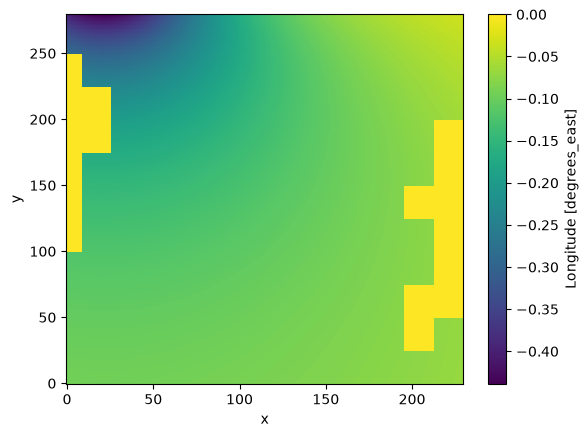

In [29]:
(nemo_ssh.nav_lon - nemo_ubar.nav_lon).plot()

In [5]:
nemo_ssh.isnull().any().compute()

<xarray.Dataset> Size: 3B
Dimensions:               ()
Data variables:
    time_centered_bounds  bool 1B False
    time_counter_bounds   bool 1B False
    ssh                   bool 1B True
Attributes:
    name:         NAA10KM_1h_19800101_19801231_ssh
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2026-Mar-09 19:50:28 GMT
    uuid:         570bc69b-c0fc-4aa8-aa7a-be489da1921e

# Downsampling to 3-hourly for NEMO

In [6]:
print(forcing['u10'].time[:10])

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['1980-01-01T00:00:00.000000000', '1980-01-01T03:00:00.000000000',
       '1980-01-01T06:00:00.000000000', '1980-01-01T09:00:00.000000000',
       '1980-01-01T12:00:00.000000000', '1980-01-01T15:00:00.000000000',
       '1980-01-01T18:00:00.000000000', '1980-01-01T21:00:00.000000000',
       '1980-01-02T00:00:00.000000000', '1980-01-02T03:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 80B 1980-01-01 ... 1980-01-02T03:00:00
Attributes:
    standard_name:  time
    axis:           T


In [7]:
print(nemo_ssh.time_centered[:10].values)

['1980-01-01T00:30:00.000000000' '1980-01-01T01:30:00.000000000'
 '1980-01-01T02:30:00.000000000' '1980-01-01T03:30:00.000000000'
 '1980-01-01T04:30:00.000000000' '1980-01-01T05:30:00.000000000'
 '1980-01-01T06:30:00.000000000' '1980-01-01T07:30:00.000000000'
 '1980-01-01T08:30:00.000000000' '1980-01-01T09:30:00.000000000']


In [8]:
print(nemo_ssh.time_counter.attrs)

{'axis': 'T', 'standard_name': 'time', 'long_name': 'Time axis', 'time_origin': '1900-01-01 00:00:00', 'bounds': 'time_counter_bounds'}


In [9]:
ssh_3h = nemo_ssh["ssh"].isel(time_counter=slice(None, None, 3))
ubar_3h = nemo_ubar["ubar"].isel(time_counter=slice(None, None, 3))
vbar_3h = nemo_vbar["vbar"].isel(time_counter=slice(None, None, 3))

In [10]:
print(ssh_3h.time_counter[:10].values)

['1980-01-01T00:30:00.000000000' '1980-01-01T03:30:00.000000000'
 '1980-01-01T06:30:00.000000000' '1980-01-01T09:30:00.000000000'
 '1980-01-01T12:30:00.000000000' '1980-01-01T15:30:00.000000000'
 '1980-01-01T18:30:00.000000000' '1980-01-01T21:30:00.000000000'
 '1980-01-02T00:30:00.000000000' '1980-01-02T03:30:00.000000000']


# Cropping the ERA5 data to the NEMO domain

In [11]:
print("ERA5:", forcing.lon.min().item(), forcing.lon.max().item())

ERA5: -180.0 179.75


In [12]:
lat_min = float(nemo_ssh['ssh'].nav_lat.min())
lat_max = float(nemo_ssh['ssh'].nav_lat.max())

lon_min = float(nemo_ssh['ssh'].nav_lon.min())
lon_max = float(nemo_ssh['ssh'].nav_lon.max())

print(lat_min, lat_max)
print(lon_min, lon_max)

-1.0 84.44892883300781
-42.09150314331055 45.71455764770508


In [13]:
buffer = 5  # degrees

era5_crop = forcing.sel(
    lat=slice(lat_max + buffer, lat_min - buffer),  # ERA5 latitude decreases
    lon=slice(lon_min - buffer, lon_max + buffer)
)
print("ERA5:", era5_crop.lon.min().item(), era5_crop.lon.max().item())

ERA5: -47.0 50.5


# Normalising the data
By mean and standard deviation for each variable

In [14]:
var_names = ["u10", "v10", "msl"]
mean = {v: era5_crop[v].mean(dim=("time", "lat", "lon"), skipna=True) for v in var_names}
std = {v: era5_crop[v].std(dim=("time", "lat", "lon"), skipna=True) for v in var_names}

In [15]:
forcing_norm = xr.Dataset({
    v: (era5_crop[v] - mean[v]) / std[v]
    for v in var_names
})

In [16]:

mean = {
    "ssh": ssh_3h.mean(dim=("time_counter", "y", "x"), skipna=True),
    "ubar": ubar_3h.mean(dim=("time_counter", "y", "x"), skipna=True),
    "vbar": vbar_3h.mean(dim=("time_counter", "y", "x"), skipna=True),
}

std = {
    "ssh": ssh_3h.std(dim=("time_counter", "y", "x"), skipna=True),
    "ubar": ubar_3h.std(dim=("time_counter", "y", "x"), skipna=True),
    "vbar": vbar_3h.std(dim=("time_counter", "y", "x"), skipna=True),
}

In [17]:
ssh_norm = (ssh_3h - mean["ssh"]) / std["ssh"]
ubar_norm = (ubar_3h - mean["ubar"]) / std["ubar"]
vbar_norm = (vbar_3h - mean["vbar"]) / std["vbar"]

In [18]:
ssh_norm = ssh_norm.rename({"time_counter": "time"})
ubar_norm = ubar_norm.rename({"time_counter": "time"})
vbar_norm = vbar_norm.rename({"time_counter": "time"})

# Checking they are normalised

In [19]:

print(forcing_norm["v10"].values.std())

1.0


In [20]:
import numpy as np
lon_target = era5_crop["lon"].copy()
lon_target = np.mod(era5_crop["lon"], 360)

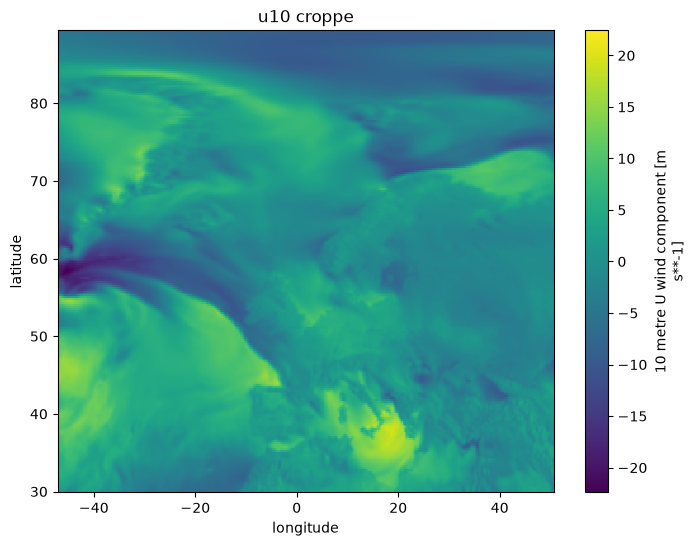

In [21]:
import matplotlib.pyplot as plt

u10_crop= era5_crop["u10"]   # or ssh_masked if you want land masked to 0

field = u10_crop.isel(time=0).compute()   # choose one timestep

field.plot(
    x="lon",
    y="lat",
    cmap="viridis",
    figsize=(8, 6)
)

plt.title("u10 croppe")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

# Masking the NEMO data using the landmask

In [22]:
# Mask the ocean dataset by land
# `top_level` is the mask from the bathymetry file.
# On the NEMO grid, ocean cells are usually marked with 1 and land cells with 0.
mask = bathy["top_level"] == 1

ssh_masked = ssh_norm.where(mask, other=0).assign_coords(
    nav_lat=nemo_ssh["nav_lat"],
    nav_lon=nemo_ssh["nav_lon"],
)

ubar_masked = ubar_norm.where(mask, other=0).assign_coords(
    nav_lat=nemo_ssh["nav_lat"],
    nav_lon=nemo_ssh["nav_lon"],
)

vbar_masked = vbar_norm.where(mask, other=0).assign_coords(
    nav_lat=nemo_ssh["nav_lat"],
    nav_lon=nemo_ssh["nav_lon"],
)

print(ssh_masked.values)
print(ssh_masked["nav_lat"].shape)
print(ssh_masked["nav_lon"].shape)

print('Ocean mask count:', int(mask.sum().values))
print('Land mask count:', int((~mask).sum().values))

[[[-0.7175165  -0.709866   -0.71102655 ...  0.          0.
    0.        ]
  [-0.7345418  -0.7225518  -0.7134596  ...  0.          0.
    0.        ]
  [-0.7499671  -0.7362549  -0.71994793 ...  0.          0.
    0.        ]
  ...
  [-0.66676825 -0.65553063 -0.643564   ... -0.18186659 -0.17218308
   -0.16563222]
  [-0.6092466  -0.60091674 -0.5912005  ... -0.19160017 -0.18349038
   -0.17676827]
  [-0.5606999  -0.555232   -0.54813236 ... -0.19941773 -0.19467025
   -0.18855448]]

 [[-0.66345894 -0.6593207  -0.6628444  ...  0.          0.
    0.        ]
  [-0.68192595 -0.67306525 -0.66562337 ...  0.          0.
    0.        ]
  [-0.6987498  -0.68771046 -0.6726602  ...  0.          0.
    0.        ]
  ...
  [-0.65803105 -0.6470053  -0.63499093 ... -0.14555122 -0.12889425
   -0.11523563]
  [-0.6005653  -0.5924032  -0.5825511  ... -0.15525475 -0.14041181
   -0.1270888 ]
  [-0.5519068  -0.5466145  -0.5393376  ... -0.16294092 -0.1516824
   -0.13934514]]

 [[-0.557502   -0.55623525 -0.5615790

# Interpolate the variables to the SSH

In [23]:
# The coordinates we want to interpolate to.
target_lat = nemo_ssh["nav_lat"].values
target_lon = nemo_ssh["nav_lon"].values

In [24]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

target_lat = nemo_ssh["nav_lat"].values
target_lon = nemo_ssh["nav_lon"].values
lat, lon = era5_crop["u10"]["lat"].values, era5_crop["u10"]["lon"].values
print(lon.min(), lon.max())
print(target_lon.min(), target_lon.max())

def _interp_2d(arr, lat, lon, target_lat, target_lon):
    pts = np.column_stack([target_lat.ravel(),
                           target_lon.ravel()])

    interp = RegularGridInterpolator(
        (lat, lon),
        arr,
        bounds_error=False,
        fill_value=np.nan
    )

    return interp(pts).reshape(target_lat.shape)

def interpolate_era5_to_ssh(da, target_lat, target_lon):
    da = da.transpose("time", "lat", "lon")
    lat, lon = da["lat"].values, da["lon"].values
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        da = da.isel(lat=slice(None, None, -1))

    result = xr.apply_ufunc(
        _interp_2d, da, lat, lon, target_lat, target_lon,
        input_core_dims=[["lat", "lon"], [], [], [], []],
        output_core_dims=[["y", "x"]],
        dask="parallelized",
        output_dtypes=[np.float32],
        dask_gufunc_kwargs={"output_sizes": {"y": target_lat.shape[0], "x": target_lat.shape[1]}},
    )
    return result

u10_on_ssh = era5_crop["u10"].interp(
    lat=xr.DataArray(target_lat, dims=("y", "x")),
    lon=xr.DataArray(target_lon, dims=("y", "x")),
    method="linear",
)

v10_on_ssh = era5_crop["v10"].interp(
    lat=xr.DataArray(target_lat, dims=("y", "x")),
    lon=xr.DataArray(target_lon, dims=("y", "x")),
    method="linear",
)

msl_on_ssh = era5_crop["msl"].interp(
    lat=xr.DataArray(target_lat, dims=("y", "x")),
    lon=xr.DataArray(target_lon, dims=("y", "x")),
    method="linear",
)


u10_on_ssh = interpolate_era5_to_ssh(era5_crop["u10"], target_lat, target_lon)
v10_on_ssh = interpolate_era5_to_ssh(era5_crop["v10"], target_lat, target_lon)
msl_on_ssh = interpolate_era5_to_ssh(era5_crop["msl"], target_lat, target_lon)

#ubar_on_ssh = ubar_norm
#vbar_on_ssh = vbar_norm

-47.0 50.5
-42.091503 45.714558


ValueError: Dimension `'__loopdim1__'` with different lengths in arrays

In [ ]:
final_ds = xr.Dataset({
    "u10": u10_on_ssh, "v10": v10_on_ssh, "msl": msl_on_ssh,
    "ssh": ssh_masked, "ubar": ubar_masked, "vbar": vbar_masked,
})
final_ds.to_zarr("data/preprocessed_nordic_seas.zarr", mode="w")

NameError: name 'u10_on_ssh' is not defined

In [ ]:
print(u10_on_ssh['y'])
print(ssh_masked['y'])
#print(u10_on_ssh['lat'])


<xarray.DataArray 'y' (y: 280)> Size: 2kB
[280 values with dtype=int64]
Coordinates:
  * y        (y) int64 2kB 0 1 2 3 4 5 6 7 8 ... 272 273 274 275 276 277 278 279
<xarray.DataArray 'y' (y: 280)> Size: 2kB
[280 values with dtype=int64]
Dimensions without coordinates: y


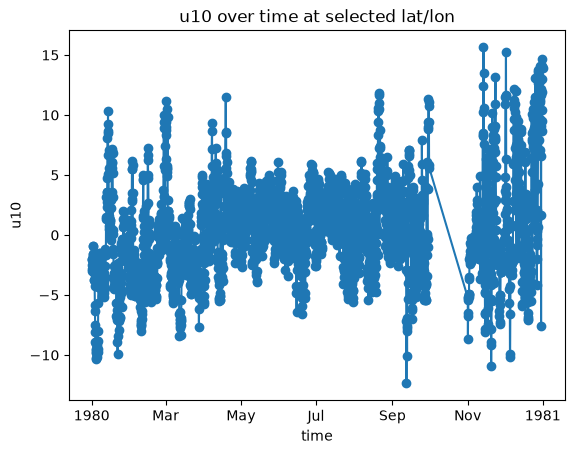

In [ ]:
import matplotlib.pyplot as plt

# Pick one variable, e.g. u10
series = forcing["u10"].sel(
    lat=60.0,      # replace with your chosen latitude
    lon=5.0,       # replace with your chosen longitude
    method="nearest"
).compute()

series.plot.line(x="time", marker="o")
plt.title("u10 over time at selected lat/lon")
plt.xlabel("time")
plt.ylabel("u10")
plt.show()

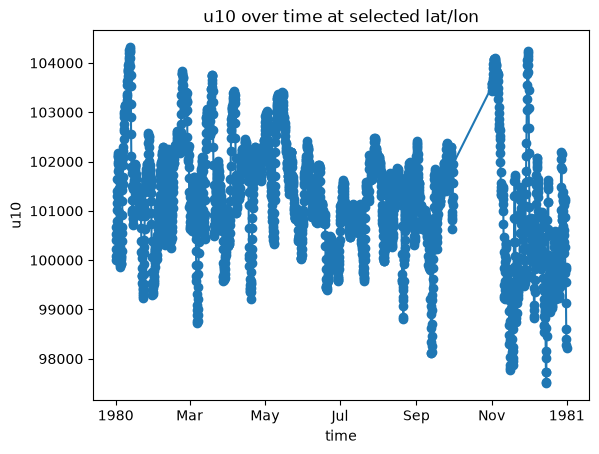

In [ ]:
import matplotlib.pyplot as plt

# Pick one variable, e.g. u10
series = forcing["msl"].sel(
    lat=60.0,      # replace with your chosen latitude
    lon=5.0,       # replace with your chosen longitude
    method="nearest"
).compute()

series.plot.line(x="time", marker="o")
plt.title("u10 over time at selected lat/lon")
plt.xlabel("time")
plt.ylabel("u10")
plt.show()